In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [9]:
import warnings
warnings.filterwarnings("ignore")
from transformers import logging
logging.set_verbosity_error()

In [2]:
from langchain_groq import ChatGroq

GROQ_API_KEY = os.getenv("GROQ_API_KEY")

llm = ChatGroq(
    api_key=GROQ_API_KEY,
    model= "llama-3.1-8b-instant"
)

d:\agentic-rag-lab\.myvenvr\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from typing import TypedDict
class STATE(TypedDict):
    question : str
    document : list[str]
    answer : str
    need_retrive : bool

In [4]:
from langchain_core.prompts import ChatPromptTemplate
PROMPT = ChatPromptTemplate.from_messages([
    ("system", """You are an AI that decides whether 
    external documents should be retrieved to answer a question.
    
    Reply only with 'yes' or 'no'.
    
    Say 'yes' when:
    - Question is about a specific paper, book, or document
    - Technical/academic concepts that need precise definitions
    - Question involves specific facts, data, or details
    - Current events or info beyond knowledge cutoff
    
    Say 'no' when:
    - Simple math or logic
    - Casual conversation or greetings
    - Creative writing
    - Very basic general knowledge (e.g. "what is 2+2")
    """),
    ("human", "Question: {question}")
])

def grade_NODE(state: STATE):
    question = state["question"]

    response = llm.invoke(PROMPT.format_messages(question = question))

    print(f"🤖 Grader raw response: '{response.content}'")  # ← add this

    need_retrive = response.content.strip().lower() == "yes" # get dicision 

    print(f"decision:- {"Retrive the data" if need_retrive else "Answer Genrate"} ")

    return {"need_retrive": need_retrive}


In [5]:
def condition(state:STATE):
    if state['need_retrive']:
        return "RETRIVE"
    else:
        return "GENERATE"

In [6]:
from src.loader import load_and_split
from src.vectorstore import get_vectorstore

PDF_PATH = "D:\\agentic-rag-lab\\attention.pdf"

def retrive_NODE(state: STATE):
    question = state["question"]
    print(f"📄 Retrieving docs for: {question}")

    chunks = load_and_split(PDF_PATH)
    store = get_vectorstore(chunks)

    result = store.similarity_search(question, k = 3)

    docs = [doc.page_content for doc in result]

    return {"document": docs}


def generate_NODE(state: STATE):
    question = state['question']
    document = state.get('document', [])

    if document:
        context = "\n".join(document)
        prompt = f"""Answer based on the provided documents:

        Documents:- {context}

        Question:- {question}

        Answer:- 
        """    
    else:
        prompt = f"Answer this question directly: {question}"

    response = llm.invoke(prompt)

    return {'answer': response.content}


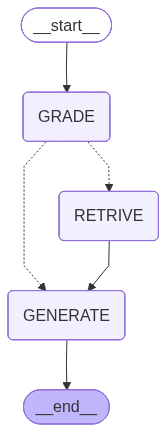

In [ ]:
from langgraph.graph import StateGraph, START,END

g = StateGraph(STATE)
g.add_node('GRADE', grade_NODE)
g.add_node('RETRIVE', retrive_NODE)
g.add_node('GENERATE', generate_NODE)

g.add_edge(START, 'GRADE')
g.add_conditional_edges(
    'GRADE',
    condition,
    {
        "RETRIVE" : "RETRIVE",
        "GENERATE" : "GENERATE"
    }
)
g.add_edge('RETRIVE','GENERATE')
g.add_edge('GENERATE', END)

app = g.compile()
app

In [14]:
result = app.invoke({"question": "what is Large language model"})
print(result)

🤖 Grader raw response: 'no'
decision:- Answer Genrate 
{'question': 'what is Large language model', 'answer': "A Large Language Model (LLM) is a type of artificial intelligence (AI) designed to process and understand human language. It's a computer program that can analyze, generate, and respond to natural language inputs, such as text or speech, in a way that's similar to how a human would.", 'need_retrive': False}
